In [10]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file == "fact_nav.csv":
            print(os.path.join(root, file))

..\dashboards\fact_nav.csv


In [8]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if file == "fact_nav.csv":
            print(os.path.join(root, file))

..\dashboards\fact_nav.csv


Using file: ..\dashboards\fact_nav.csv
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='str')
Mean Return: 0.000883839064603624
Volatility: 0.09256127554798073


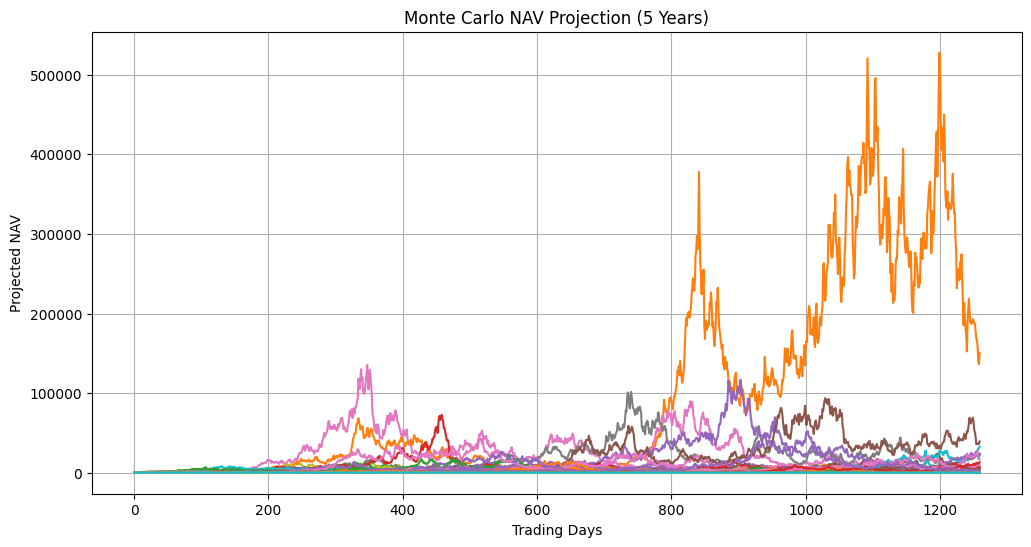


Average Future NAV: 428.45
Minimum Future NAV: 0.0
Maximum Future NAV: 150345.24

5% Confidence: 0.01
95% Confidence: 594.4

File Saved: monte_carlo_projection.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Find fact_nav.csv automatically
nav_file = None

for root, dirs, files in os.walk(".."):
    if "fact_nav.csv" in files:
        nav_file = os.path.join(root, "fact_nav.csv")
        break

if nav_file is None:
    raise FileNotFoundError("fact_nav.csv not found in project")

print("Using file:", nav_file)

# Load NAV data
nav = pd.read_csv(nav_file)

# Check columns
print(nav.head())
print(nav.columns)

# Replace 'nav' below if your NAV column has a different name
nav["daily_return"] = nav["nav"].pct_change()

returns = nav["daily_return"].dropna()

# Statistics
mu = returns.mean()
sigma = returns.std()

print("Mean Return:", mu)
print("Volatility:", sigma)

# Monte Carlo Parameters
num_simulations = 1000
num_days = 252 * 5

initial_nav = nav["nav"].iloc[-1]

simulation_df = np.zeros((num_days, num_simulations))

# Simulation
for sim in range(num_simulations):

    prices = [initial_nav]

    for day in range(num_days):

        shock = np.random.normal(mu, sigma)

        next_price = prices[-1] * (1 + shock)

        prices.append(next_price)

    simulation_df[:, sim] = prices[1:]

# Plot
plt.figure(figsize=(12,6))
plt.plot(simulation_df)
plt.title("Monte Carlo NAV Projection (5 Years)")
plt.xlabel("Trading Days")
plt.ylabel("Projected NAV")
plt.grid(True)
plt.show()

# Results
final_values = simulation_df[-1]

print("\nAverage Future NAV:", round(final_values.mean(), 2))
print("Minimum Future NAV:", round(final_values.min(), 2))
print("Maximum Future NAV:", round(final_values.max(), 2))

lower = np.percentile(final_values, 5)
upper = np.percentile(final_values, 95)

print("\n5% Confidence:", round(lower, 2))
print("95% Confidence:", round(upper, 2))

# Save Output
result = pd.DataFrame({
    "Final_NAV": final_values
})

result.to_csv("monte_carlo_projection.csv", index=False)

print("\nFile Saved: monte_carlo_projection.csv")